In [11]:
import numpy as np
import diplib as dip
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

DATA_DIR   = Path.cwd()                       # maybe change to ur data directory
FNAME      = "w8t1t2_d7_{}.tif"               # filename template
EMBRYO_IDS = [f"{i:02d}" for i in range(1, 59)]   # 58 unique 

## 1. Segmentation technique 


**Pre-processing & algorithm**
1. **Estimate the background colour** as the median RGB of the four image
   corners background dominates the corners (for most images) the median ignores any stray
   material that touches a corner.
2. **Colour-distance map** $d(x) = ‖ rgb(x) − bg ‖₂$. Every embryo part
lies far from the background colour so they should retain high values
3. **Gaussian smoothing** (σ = 3) to suppress pixel noise/speckle.
4. **Threshold** 
5. **Morphological clean-up:** closing -> fill holes ->
   area-opening (removes small background debris) -> keep the largest connected
   component.



In [12]:
def load_rgb(embryo_id):
    """Load one embryo's image as a RGB array."""
    img=dip.ImageRead(str(DATA_DIR / FNAME.format(embryo_id)))
    #img.Show()
    array=np.asarray(img)
    return array

load_rgb(EMBRYO_IDS[0])  # test loading one image

def estimate_background(rgb, s=100):
    """Background colour = median RGB over the four corner patches."""
    corners = np.concatenate([
        rgb[:s, :s].reshape(-1, 3),  rgb[:s, -s:].reshape(-1, 3),
        rgb[-s:, :s].reshape(-1, 3), rgb[-s:, -s:].reshape(-1, 3)])
    return np.median(corners, axis=0)


def keep_largest(mask):
    labs  = dip.Label(mask)
    meas = dip.MeasurementTool.Measure(labs, None, ["Size"])
    ids  = list(meas.Objects())
    if not ids:
        return mask
    biggest = ids[int(np.argmax([meas[i]["Size"][0] for i in ids]))]
    return dip.Image(np.asarray(labs) == biggest)


def segment_embryo(rgb, sigma=3.0, r=9, min_size=3000):
    """Return a boolean mask of the embryo (colour-distance + triangle threshold)."""
    bg     = estimate_background(rgb)
    dist   = (((rgb - bg)**2).sum(axis=2))                   # 1. distance pythagorean since we have 3D RGB data
    smooth = dip.Gauss(dip.Image(dist), sigma)               # 2. noise suppression
    mask   = dip.Threshold(smooth)[0] > 0                    # 3. threshold and extract mask
    mask   = dip.Closing(mask, dip.SE(r, "elliptic"))        # 4. close gaps
    mask   = dip.FillHoles(mask)                             # 5. fill interior holes
    mask   = dip.AreaOpening(mask, filterSize=min_size)      # 6. drop small debris
    mask   = keep_largest(mask)                              # 7. largest object only
    return np.asarray(mask)


def crop_to_mask(img, mask, pad=40):
    """Crop the image to the bounding box of the mask"""
    ys, xs = np.where(mask)
    if len(ys) == 0:
        return img
    y0, y1 = max(ys.min() - pad, 0), min(ys.max() + pad, mask.shape[0])
    x0, x1 = max(xs.min() - pad, 0), min(xs.max() + pad, mask.shape[1])
    return img[y0:y1, x0:x1]


def to_uint8(rgb):
    """16-bit float RGB -> 8-bit for display."""
    return (rgb / 256.0).clip(0, 255).astype(np.uint8)

In [13]:
#lists to store results of segmentation and area measurement + original images for display
panel_orig, panel_mask, areas = [], [], []

for eid in EMBRYO_IDS:
    rgb  = load_rgb(eid)
    mask = segment_embryo(rgb)
    panel_orig.append(to_uint8(crop_to_mask(rgb,  mask)))
    panel_mask.append(crop_to_mask(mask, mask))
    areas.append(int(mask.sum()))
    print(f"embryo {eid}:  area = {areas[-1]:>7d} px")

print(f"\nSegmented {len(panel_mask)} embryos.")

embryo 01:  area =  225251 px
embryo 02:  area =  157846 px
embryo 03:  area =  168853 px
embryo 04:  area =  166085 px
embryo 05:  area =  219523 px
embryo 06:  area =  168892 px
embryo 07:  area =  244691 px
embryo 08:  area =  170001 px
embryo 09:  area =  199484 px
embryo 10:  area =  239892 px
embryo 11:  area =  211089 px
embryo 12:  area =  182585 px
embryo 13:  area =  185020 px
embryo 14:  area =  228252 px
embryo 15:  area =  214520 px
embryo 16:  area =  153209 px
embryo 17:  area =   81472 px
embryo 18:  area =  195662 px
embryo 19:  area =  233954 px
embryo 20:  area =  185037 px
embryo 21:  area =  243362 px
embryo 22:  area =   81681 px
embryo 23:  area =  214484 px
embryo 24:  area =  190704 px
embryo 25:  area =  158819 px
embryo 26:  area =  213449 px
embryo 27:  area =   72298 px
embryo 28:  area =  199582 px
embryo 29:  area =  152886 px
embryo 30:  area =  167401 px
embryo 31:  area =  243644 px
embryo 32:  area =  249002 px
embryo 33:  area =  164051 px
embryo 34:

## 2. Panel of the original images (Part 1.2)

All 58 embryos are cropped to their bounding box and rescaled 

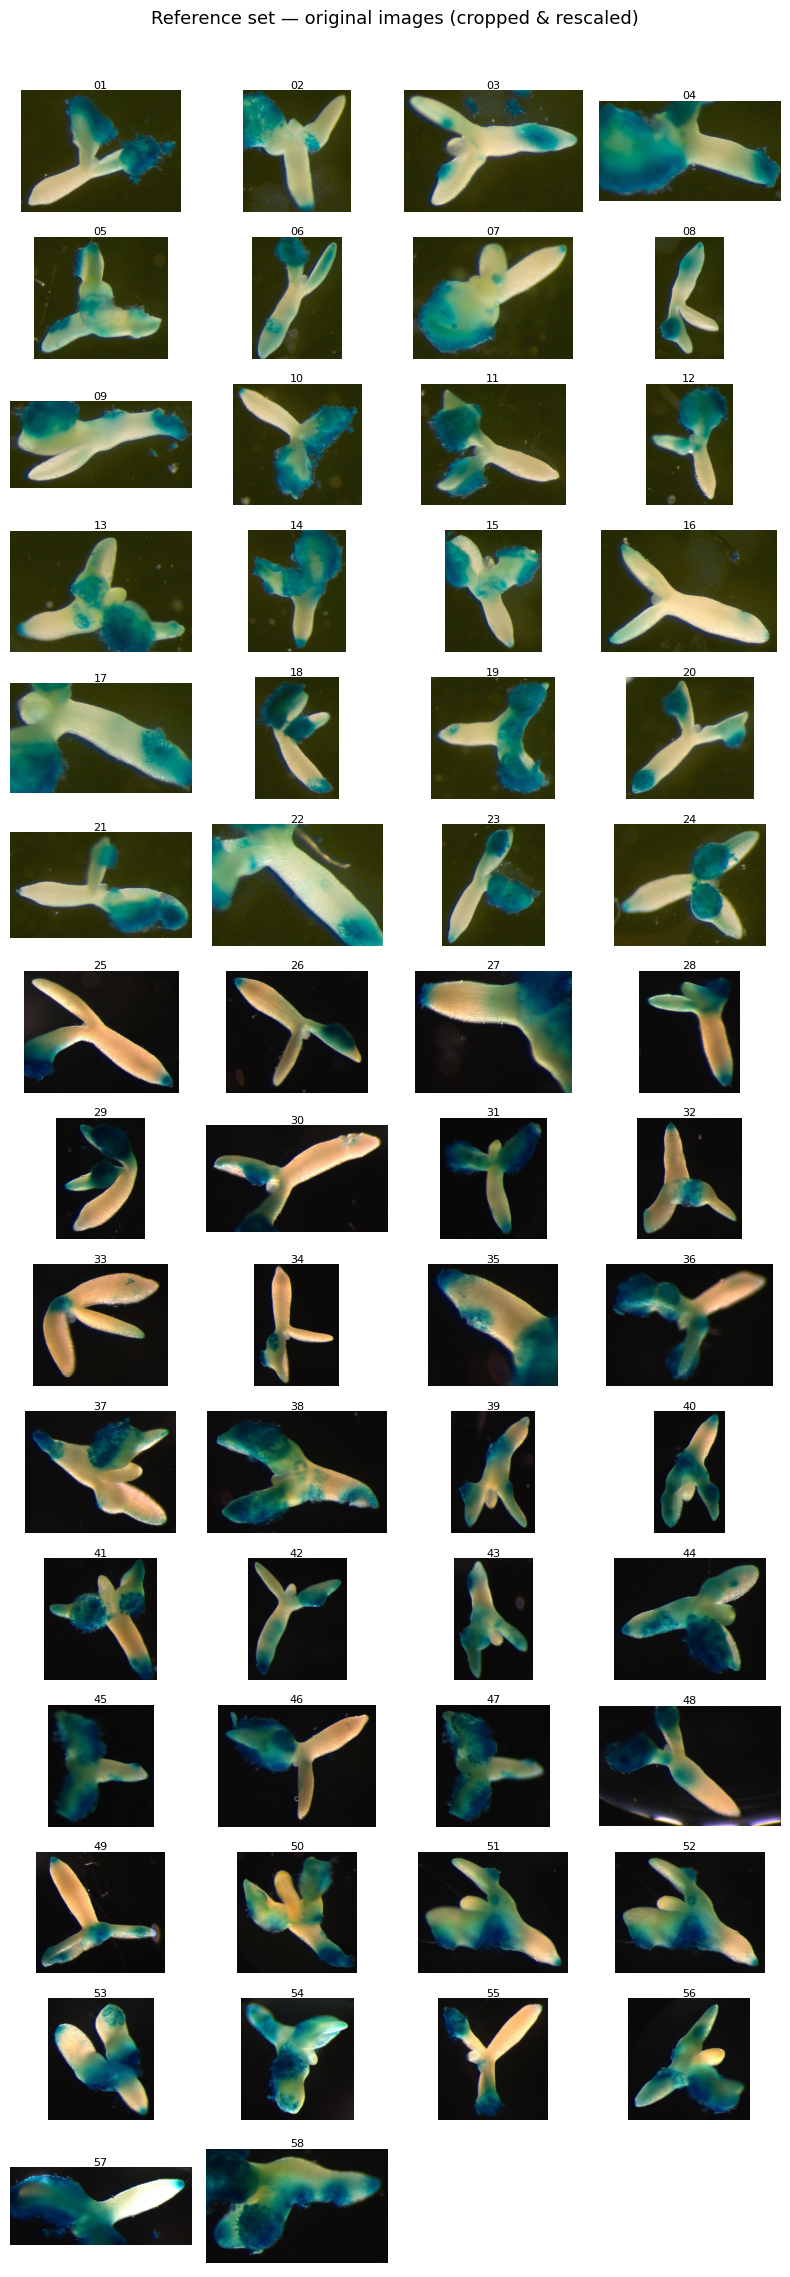

In [14]:
def show_panel(images, labels, nrows=15, ncols=4, binary=False, suptitle=None):
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.0, nrows * 1.5))
    for k, ax in enumerate(axes.ravel()):
        ax.axis("off")
        if k < len(images):
            ax.imshow(images[k], cmap="gray" if binary else None)
            ax.set_title(labels[k], fontsize=8, pad=1)
    if suptitle:
        fig.suptitle(suptitle, fontsize=13, y=1.01)
    plt.tight_layout()
    return fig

fig = show_panel(panel_orig, EMBRYO_IDS,
                 suptitle="Reference set — original images (cropped & rescaled)")
plt.show()

## 3. Panel of the binary masks  - method works for black background but not for green 



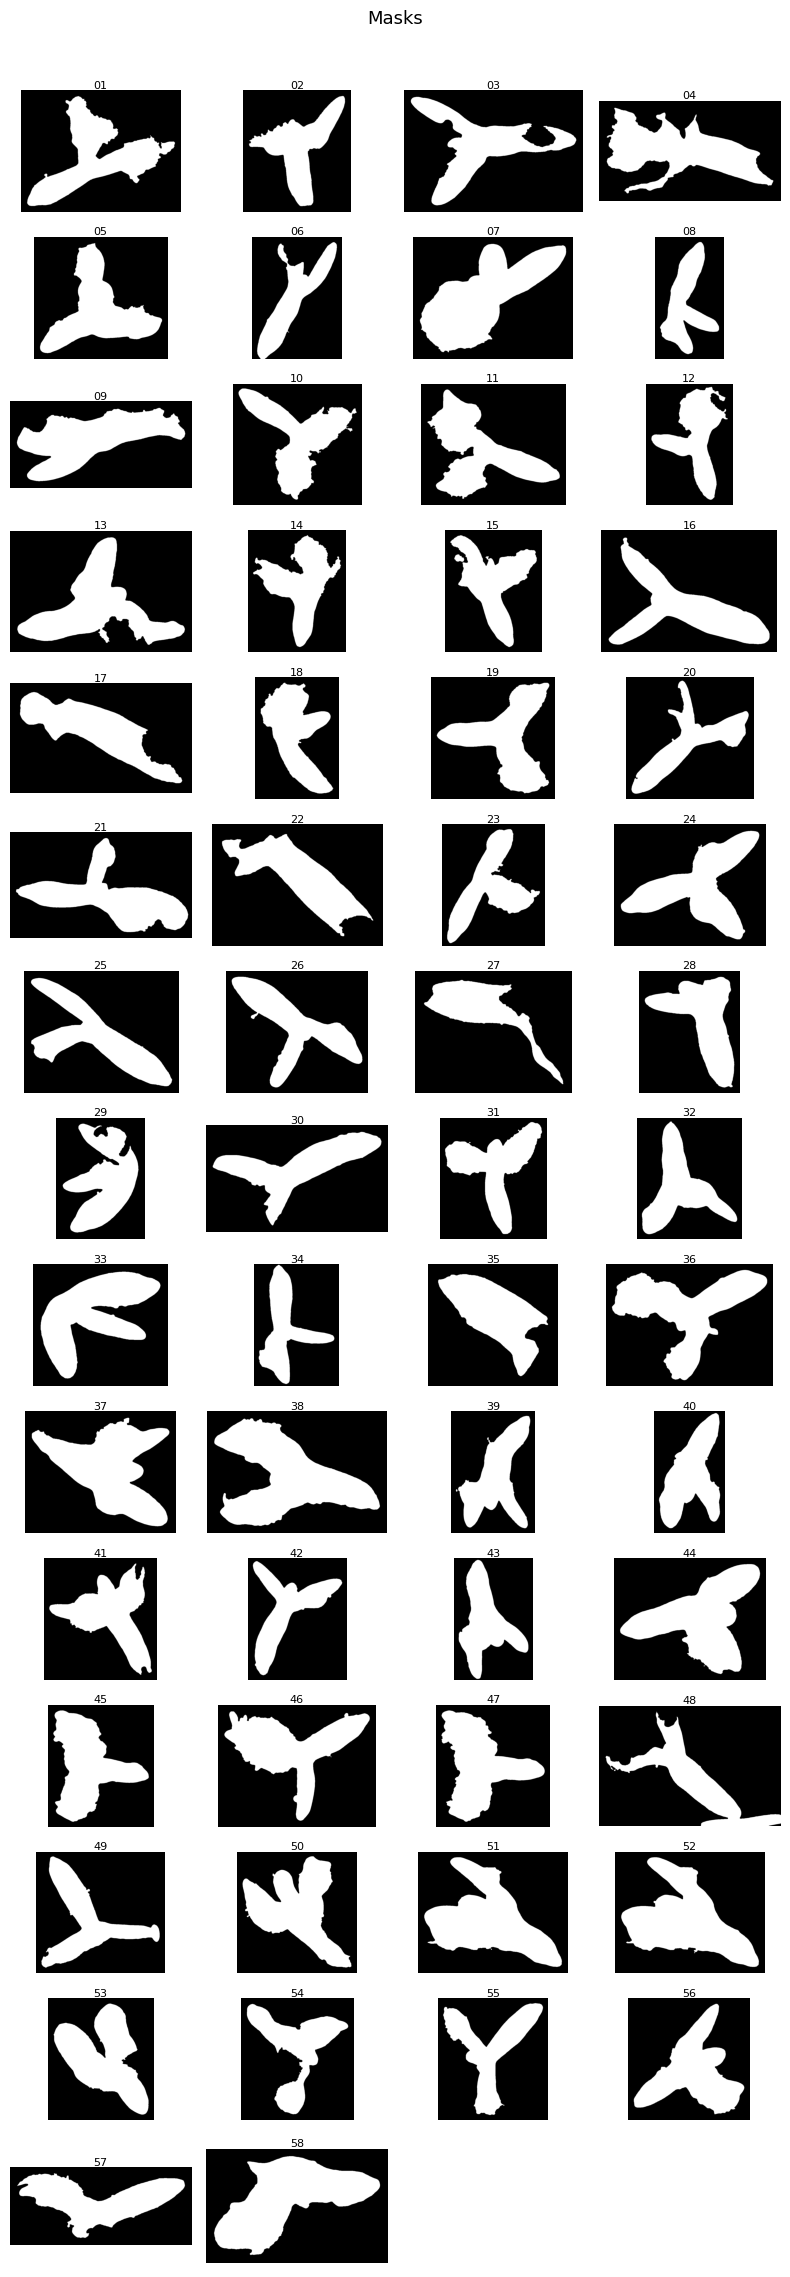

In [15]:
fig = show_panel(panel_mask, EMBRYO_IDS, binary=True,
                 suptitle="Masks")
plt.show()

---
# Part 2 — Shape, size and gene-expression measurements



## 2.1 — Size and shape features


In [16]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


def blue_mask(rgb, mask, frac=0.40, erode=6, min_speck=150):
    """Boolean mask of blue (gene-expression) pixels inside the embryo.
    f_B = B/(R+G+B) > frac then pixel is blue."""
    rgb = rgb.astype(np.float64)  # 16-bit to  float. If we don't do this, the division will be wrong and frac_blue will be zero everywhere.
    interior = np.asarray(dip.BinaryErosion(dip.Image(mask), 1, erode)).astype(bool)
    R, G, B  = rgb[..., 0], rgb[..., 1], rgb[..., 2]
    frac_blue = B / (R + G + B + 1e-6)  #  avoid division by zero
    bm = (frac_blue > frac) & interior
    bm = np.asarray(dip.AreaOpening(dip.Image(bm), filterSize=min_speck)).astype(bool)
    return bm


def measure_shape(mask):
    """Size + shape of a single-object boolean mask"""
    lab = dip.Label(dip.Image(mask))
    m = dip.MeasurementTool.Measure(
              lab, None, ["Size", "Perimeter", "Roundness", "Solidity"])
    
    g = lambda k: float(m[1][k][0])
    return dict(area=g("Size"), perimeter=g("Perimeter"), roundness=g("Roundness"),
                solidity=g("Solidity"))

In [17]:
masks, blue_masks, records = {}, {}, []
for eid in EMBRYO_IDS:
    rgb  = load_rgb(eid)
    mask = segment_embryo(rgb)
    bm   = blue_mask(rgb, mask)
    masks[eid], blue_masks[eid] = mask, bm
    sh = measure_shape(mask)
    blue_abs = int(bm.sum())
    records.append({"id": eid, **sh, "blue_abs": blue_abs,
                    "blue_rel": blue_abs / sh["area"]})

features = pd.DataFrame(records).set_index("id")
show = features.copy()
show["area"]      = show["area"].astype(int)
show["perimeter"] = show["perimeter"].round(0).astype(int)
show[["roundness", "solidity", "blue_rel"]] = \
        show[["roundness", "solidity", "blue_rel"]].round(3)
show

,area,perimeter,roundness,solidity,blue_abs,blue_rel
id,,,,,,
01,225251,3700,0.207,0.575,83229,0.369
02,157846,2468,0.326,0.659,7691,0.049
03,168853,3431,0.180,0.502,3515,0.021
04,166085,3323,0.189,0.603,64919,0.391
05,219523,2788,0.355,0.649,24186,0.110
06,168892,2942,0.245,0.584,13320,0.079
07,244691,2618,0.448,0.792,65149,0.266
08,170001,2629,0.309,0.650,29808,0.175
09,199484,2732,0.336,0.735,32632,0.164


Viusualisation

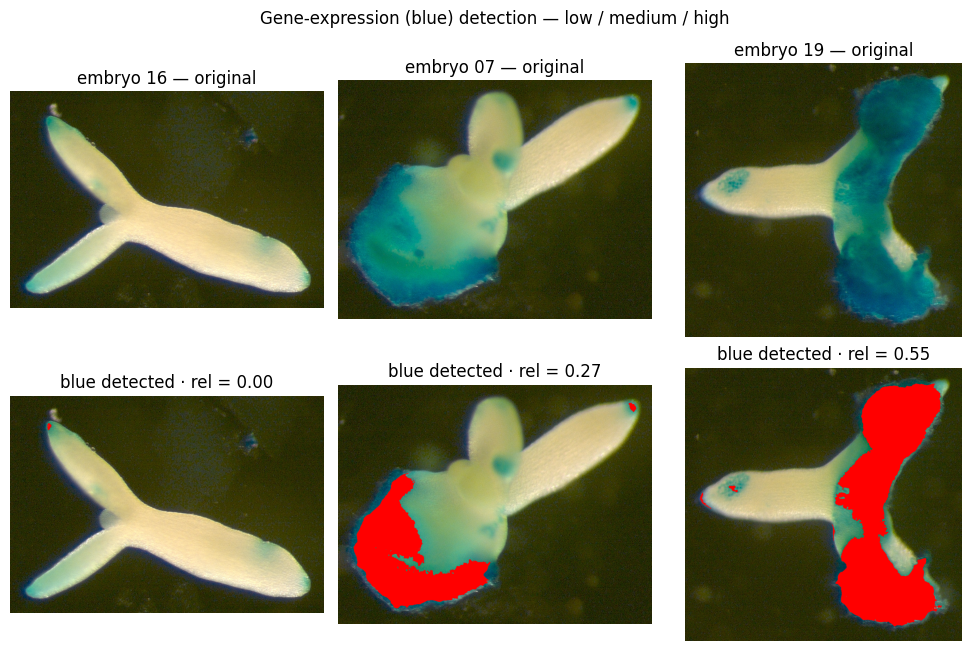

In [18]:
def overlay_blue(eid, colour=(255, 0, 0)):
    rgb  = load_rgb(eid)
    disp = to_uint8(rgb).copy()
    disp[blue_masks[eid]] = colour                       
    return crop_to_mask(disp, masks[eid]), crop_to_mask(to_uint8(rgb), masks[eid])

clean    = features[features.area > 120000].sort_values("blue_rel")   # representative
examples = [clean.index[0], clean.index[len(clean)//2], clean.index[-1]]

fig, ax = plt.subplots(2, 3, figsize=(10, 6.6))
for j, eid in enumerate(examples):
    over, orig = overlay_blue(eid)
    ax[0, j].imshow(orig); ax[0, j].axis("off"); ax[0, j].set_title(f"embryo {eid} — original")
    ax[1, j].imshow(over); ax[1, j].axis("off")
    ax[1, j].set_title(f"blue detected · rel = {features.loc[eid, 'blue_rel']:.2f}")
fig.suptitle("Gene-expression (blue) detection — low / medium / high", fontsize=12)
plt.tight_layout(); plt.show()

## Part 3.1


Texture features table:


,blue_pixels,nonblue_pixels,blue_std,blue_uniformity,nonblue_std,nonblue_uniformity
id,,,,,,
01,32197,134899,0.050815,0.022094,0.166844,0.008476
02,65136,173399,0.057885,0.021117,0.120048,0.012838
03,24511,176445,0.065048,0.017356,0.115245,0.011270
04,211037,135122,0.059866,0.018170,0.168332,0.006883
05,21058,191669,0.057760,0.019286,0.111762,0.010393
06,21931,158575,0.053826,0.022015,0.126102,0.009689
07,66984,180648,0.049178,0.022622,0.131207,0.008841
08,12671,133984,0.050019,0.023226,0.135770,0.008632
09,23498,164530,0.055996,0.022203,0.130534,0.009590


HOG feature summaries for blue and embryo regions:


,blue_hog_16_mean,blue_hog_16_std,blue_hog_16_len,blue_hog_64_mean,blue_hog_64_std,blue_hog_64_len,embryo_hog_16_mean,embryo_hog_16_std,embryo_hog_16_len,embryo_hog_64_mean,embryo_hog_64_std,embryo_hog_64_len
id,,,,,,,,,,,,
01,0.162275,0.038009,44928,0.163224,0.033701,2268,0.162430,0.037338,90288,0.164062,0.029352,4680
02,0.162606,0.036566,75600,0.164217,0.028468,3564,0.162490,0.037078,97308,0.164213,0.028494,5184
03,0.161173,0.042440,42300,0.162277,0.037998,1980,0.161923,0.039480,99072,0.163701,0.031301,5400
04,0.162767,0.035843,102240,0.164142,0.028899,5508,0.162758,0.035885,106272,0.164189,0.028631,5508
05,0.162505,0.037014,61920,0.164321,0.027865,3240,0.162525,0.036926,93312,0.164075,0.029275,4752
06,0.162291,0.037940,61740,0.163379,0.032940,3168,0.162472,0.037158,90720,0.163886,0.030316,4536
07,0.162625,0.036480,82656,0.164126,0.028993,4212,0.162676,0.036255,88236,0.164108,0.029092,4680
08,0.161624,0.040686,42228,0.163554,0.032059,2160,0.161926,0.039469,67968,0.164014,0.029620,3528
09,0.161673,0.040492,28548,0.162528,0.036911,1008,0.161895,0.039595,69120,0.163388,0.032895,3240


HOG vector table sample:


,id,region,cell_size,vector
0,01,blue,16,"[0.20626785, 0.20626785, 0.14980258, 0.2008924..."
1,01,blue,64,"[0.21255638, 0.20549558, 0.16712545, 0.1928419..."
2,01,embryo,16,"[0.20877653, 0.14606556, 0.12842119, 0.1613081..."
3,01,embryo,64,"[0.1822679, 0.15919082, 0.1656641, 0.15824258,..."
4,02,blue,16,"[0.20972869, 0.14614552, 0.20972869, 0.1329335..."


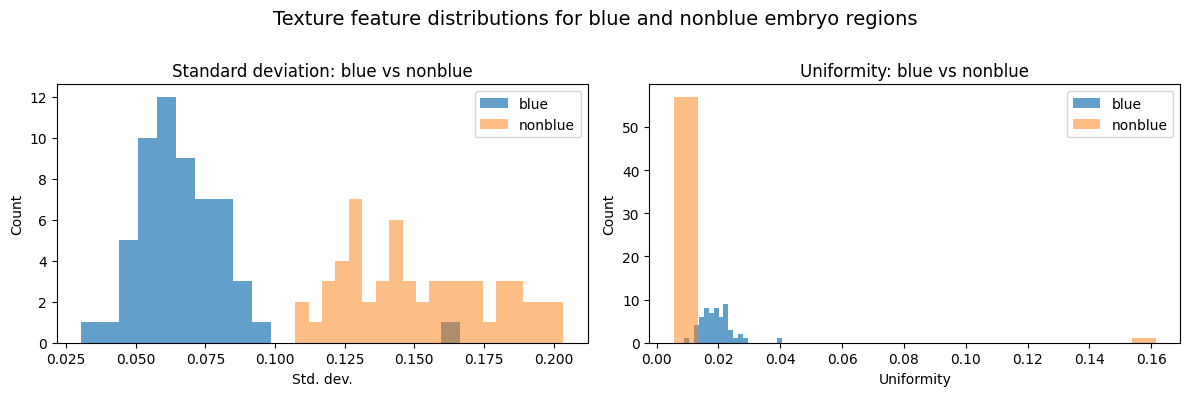

Saved: part3_1_texture_features.csv, part3_2_hog_summary.csv, and part3_2_hog_vectors.pkl


In [ ]:
import numpy as np
import pandas as pd
import diplib as dip
import matplotlib.pyplot as plt
from pathlib import Path
import tifffile as tiff
from skimage.feature import hog

DATADIR = Path( "")  # change to your data directory
FNAME = "w8t1t2_d7_{}.tif"
EMBRYOIDS = [f"{i:02d}" for i in range(1, 59)]

def loadrgb(embryoid):
    arr = tiff.imread(str(DATADIR / FNAME.format(embryoid)))
    arr = np.asarray(arr)
    if arr.ndim == 2:
        arr = np.stack([arr, arr, arr], axis=-1)
    return arr

# -----------------------------
# Embryo segmentation
# -----------------------------
def estimatebackground(rgb, s=100):
    corners = np.concatenate([
        rgb[:s, :s].reshape(-1, 3),
        rgb[:s, -s:].reshape(-1, 3),
        rgb[-s:, :s].reshape(-1, 3),
        rgb[-s:, -s:].reshape(-1, 3),
    ], axis=0)
    return np.median(corners, axis=0)

def keeplargest(mask):
    lab = dip.Label(dip.Image(mask))
    msr = dip.MeasurementTool.Measure(lab, None, ["Size"])
    ids = list(msr.Objects())
    if len(ids) == 0:
        return np.asarray(mask).astype(bool)
    biggest = max(ids, key=lambda i: msr["Size"][i][0])
    return (np.asarray(lab) == biggest)

def segmentembryo(rgb, sigma=3.0, radius=9, minsize=3000):
    bg = estimatebackground(rgb)
    dist = np.sqrt(((rgb - bg) ** 2).sum(axis=2))
    smooth = dip.Gauss(dip.Image(dist), sigma)
    mask = np.asarray(dip.Threshold(smooth)[0]).astype(bool)
    mask = dip.Closing(dip.Image(mask.astype(np.uint8)), se=dip.SE(radius, "elliptic"))
    mask = np.asarray(mask).astype(bool)
    mask = dip.FillHoles(mask)
    mask = dip.AreaOpening(mask, filterSize=minsize)
    mask = keeplargest(np.asarray(mask))
    return mask.astype(bool)

# -----------------------------
# Blue gene-expression mask
# -----------------------------
def bluemaskrgb(rgb, embryo_mask, frac=0.40, erode=6, minspeck=150):
    rgb = rgb.astype(np.float64)
    interior = np.asarray(
        dip.BinaryErosion(dip.Image(embryo_mask), iterations=erode)
    ).astype(bool)

    R = rgb[..., 0]
    G = rgb[..., 1]
    B = rgb[..., 2]

    fracblue = B / (R + G + B + 1e-6)
    bm = (fracblue > frac) & interior
    bm = np.asarray(dip.AreaOpening(dip.Image(bm), filterSize=minspeck)).astype(bool)
    return bm

# -----------------------------
# Texture features for Part 3.1
# -----------------------------
def grayscale_from_rgb(rgb):
    rgb = rgb.astype(np.float64)
    maxv = rgb.max()
    if maxv > 0:
        rgb = rgb / maxv

    gray = 0.2989 * rgb[..., 0] + 0.5870 * rgb[..., 1] + 0.1140 * rgb[..., 2]
    return gray

def texture_stats(gray, region_mask, n_bins=256):
    region_mask = region_mask.astype(bool)
    pixels = gray[region_mask]

    if pixels.size == 0:
        return np.nan, np.nan

    std_val = float(np.std(pixels))
    hist, _ = np.histogram(pixels, bins=n_bins, range=(0, 1), density=False)
    if hist.sum() == 0:
        uniformity = np.nan
    else:
        p = hist.astype(np.float64) / hist.sum()
        uniformity = float(np.sum(p ** 2))

    return std_val, uniformity

# -----------------------------
# HOG feature extraction for the blue region and whole embryo
# -----------------------------
def region_hog_features(rgb, region_mask, region_name, cell_sizes=(16, 64)):
    gray = grayscale_from_rgb(rgb)
    cropped = crop_to_mask(gray, region_mask)
    hog_data = {}
    hog_vectors = []

    for cell_size in cell_sizes:
        if cropped.size == 0 or cropped.ndim != 2 or cropped.shape[0] < cell_size * 2 or cropped.shape[1] < cell_size * 2:
            hog_vec = np.array([], dtype=np.float32)
        else:
            hog_vec = hog(
                cropped,
                orientations=9,
                pixels_per_cell=(cell_size, cell_size),
                cells_per_block=(2, 2),
                block_norm="L2-Hys",
                visualize=False,
                feature_vector=True,
            ).astype(np.float32)

        mean_key = f"{region_name}_hog_{cell_size}_mean"
        std_key = f"{region_name}_hog_{cell_size}_std"
        len_key = f"{region_name}_hog_{cell_size}_len"

        hog_data[mean_key] = float(np.mean(hog_vec)) if hog_vec.size else np.nan
        hog_data[std_key] = float(np.std(hog_vec)) if hog_vec.size else np.nan
        hog_data[len_key] = int(hog_vec.size)
        hog_vectors.append({
            "region": region_name,
            "cell_size": cell_size,
            "vector": hog_vec,
        })

    return hog_data, hog_vectors

# -----------------------------
# Run Part 3.1 on all embryos
# -----------------------------
texture_rows = []
hog_rows = []
hog_vector_rows = []

for eid in EMBRYOIDS:
    rgb = loadrgb(eid)
    embryo_mask = segmentembryo(rgb)
    blue_mask = bluemaskrgb(rgb, embryo_mask)
    nonblue_mask = embryo_mask & (~blue_mask)

    gray = grayscale_from_rgb(rgb)
    blue_std, blue_uniformity = texture_stats(gray, blue_mask)
    nonblue_std, nonblue_uniformity = texture_stats(gray, nonblue_mask)

    texture_rows.append({
        "id": eid,
        "blue_pixels": int(blue_mask.sum()),
        "nonblue_pixels": int(nonblue_mask.sum()),
        "blue_std": blue_std,
        "blue_uniformity": blue_uniformity,
        "nonblue_std": nonblue_std,
        "nonblue_uniformity": nonblue_uniformity,
    })

    blue_hog_summary, blue_hog_vectors = region_hog_features(rgb, blue_mask, "blue", cell_sizes=(16, 64))
    embryo_hog_summary, embryo_hog_vectors = region_hog_features(rgb, embryo_mask, "embryo", cell_sizes=(16, 64))

    hog_rows.append({"id": eid, **blue_hog_summary, **embryo_hog_summary})
    for v in blue_hog_vectors + embryo_hog_vectors:
        hog_vector_rows.append({"id": eid, **v})

texture_df = pd.DataFrame(texture_rows).set_index("id")
hog_df = pd.DataFrame(hog_rows).set_index("id")
hog_vector_df = pd.DataFrame(hog_vector_rows)

print("Texture features table:")
display(texture_df.round(6))
print("HOG feature summaries for blue and embryo regions:")
display(hog_df.round(6))
print("HOG vector table sample:")
display(hog_vector_df.head())

# Plot histograms for the requested texture features
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(texture_df["blue_std"].dropna(), bins=20, color="tab:blue", alpha=0.7)
axes[0].hist(texture_df["nonblue_std"].dropna(), bins=20, color="tab:orange", alpha=0.5)
axes[0].set_title("Standard deviation: blue vs nonblue")
axes[0].set_xlabel("Std. dev.")
axes[0].set_ylabel("Count")
axes[0].legend(["blue", "nonblue"])

axes[1].hist(texture_df["blue_uniformity"].dropna(), bins=20, color="tab:blue", alpha=0.7)
axes[1].hist(texture_df["nonblue_uniformity"].dropna(), bins=20, color="tab:orange", alpha=0.5)
axes[1].set_title("Uniformity: blue vs nonblue")
axes[1].set_xlabel("Uniformity")
axes[1].set_ylabel("Count")
axes[1].legend(["blue", "nonblue"])

fig.suptitle("Texture feature distributions for blue and nonblue embryo regions", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

texture_df.to_csv("part3_1_texture_features.csv")
hog_df.to_csv("part3_2_hog_summary.csv")
hog_vector_df.to_pickle("part3_2_hog_vectors.pkl")
print("Saved: part3_1_texture_features.csv, part3_2_hog_summary.csv, and part3_2_hog_vectors.pkl")


## Part 3.2


In [35]:
from skimage.transform import resize
from skimage.feature import hog
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUTDIR = Path("part3_2_hog_images")
OUTDIR.mkdir(exist_ok=True)

def bbox_crop(image, mask):
    ys, xs = np.where(mask)
    if ys.size == 0 or xs.size == 0:
        return None, None
    y0, y1 = ys.min(), ys.max() + 1
    x0, x1 = xs.min(), xs.max() + 1
    return image[y0:y1, x0:x1], mask[y0:y1, x0:x1]

def prepare_hog_input(gray, mask, out_shape=(128, 128)):
    img_crop, mask_crop = bbox_crop(gray, mask)
    if img_crop is None:
        return None
    roi = img_crop * mask_crop.astype(float)
    roi = resize(
        roi,
        out_shape,
        preserve_range=True,
        anti_aliasing=True
    ).astype(np.float32)
    return roi

def save_hog_visualization(gray, mask, eid, region_name, cell_size, outdir=OUTDIR):
    roi = prepare_hog_input(gray, mask, out_shape=(128, 128))
    if roi is None or roi.size == 0:
        return None

    _, hog_image = hog(
        roi,
        orientations=9,
        pixels_per_cell=(cell_size, cell_size),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        visualize=True,
        feature_vector=True
    )

    fig, ax = plt.subplots(1, 2, figsize=(8, 4))
    ax[0].imshow(roi, cmap="gray")
    ax[0].set_title(f"{eid} {region_name} input")
    ax[0].axis("off")

    ax[1].imshow(hog_image, cmap="gray")
    ax[1].set_title(f"HOG {cell_size} px/cell")
    ax[1].axis("off")

    fig.suptitle(f"Embryo {eid} - {region_name} - cell {cell_size}", fontsize=12)
    plt.tight_layout()

    fname = outdir / f"hog_{eid}_{region_name}_{cell_size}.png"
    fig.savefig(fname, dpi=200, bbox_inches="tight")
    plt.close(fig)
    return fname

sample_ids = ["01", "16", "57"]

for eid in sample_ids:
    rgb = loadrgb(eid)
    embryo_mask = segmentembryo(rgb)
    blue_mask = bluemaskrgb(rgb, embryo_mask)
    gray = grayscale_from_rgb(rgb)

    for cell_size in [16, 64]:
        save_hog_visualization(gray, blue_mask, eid, "blue", cell_size)
        save_hog_visualization(gray, embryo_mask, eid, "embryo", cell_size)

print("Saved HOG appendix images.")

Saved HOG appendix images.


Visualization of the HOG

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from skimage.transform import resize
from skimage.feature import hog

EMBRYOIDS = [f"{i:02d}" for i in range(1, 6)]
OUTDIR = Path("output")
OUTDIR.mkdir(exist_ok=True)

def bbox_crop(image, mask):
    ys, xs = np.where(mask)
    if ys.size == 0 or xs.size == 0:
        return None, None
    y0, y1 = ys.min(), ys.max() + 1
    x0, x1 = xs.min(), xs.max() + 1
    return image[y0:y1, x0:x1], mask[y0:y1, x0:x1]

def prepare_hog_input(gray, mask, out_shape=(128, 128)):
    img_crop, mask_crop = bbox_crop(gray, mask)
    if img_crop is None:
        return None
    roi = img_crop * mask_crop.astype(float)
    roi = resize(roi, out_shape, preserve_range=True, anti_aliasing=True).astype(np.float32)
    return roi

def compute_hog_image(roi, cell_size):
    if roi is None:
        return None
    _, hog_img = hog(
        roi,
        orientations=9,
        pixels_per_cell=(cell_size, cell_size),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        visualize=True,
        feature_vector=True
    )
    return hog_img

def save_hog_table(sample_ids, cell_size, outfile):
    rows = []
    for eid in sample_ids:
        rgb = loadrgb(eid)
        embryo_mask = segmentembryo(rgb)
        blue_mask = bluemaskrgb(rgb, embryo_mask)
        gray = grayscale_from_rgb(rgb)

        embryo_roi = prepare_hog_input(gray, embryo_mask)
        blue_roi = prepare_hog_input(gray, blue_mask)

        rows.append({
            "id": eid,
            "embryo_input": embryo_roi,
            "embryo_hog": compute_hog_image(embryo_roi, cell_size),
            "blue_input": blue_roi,
            "blue_hog": compute_hog_image(blue_roi, cell_size),
        })

    fig, axes = plt.subplots(len(rows), 4, figsize=(12, 2.5 * len(rows)))
    if len(rows) == 1:
        axes = np.array([axes])

    titles = [
        "Whole embryo input",
        f"Whole embryo HOG ({cell_size})",
        "Blue region input",
        f"Blue region HOG ({cell_size})"
    ]
    for j, t in enumerate(titles):
        axes[0, j].set_title(t, fontsize=11)

    for i, row in enumerate(rows):
        imgs = [row["embryo_input"], row["embryo_hog"], row["blue_input"], row["blue_hog"]]
        for j, img in enumerate(imgs):
            ax = axes[i, j]
            if img is None:
                ax.text(0.5, 0.5, "No data", ha="center", va="center", fontsize=10)
                ax.set_facecolor("black")
            else:
                ax.imshow(img, cmap="gray")
            ax.axis("off")
            if j == 0:
                ax.set_ylabel(row["id"], rotation=0, labelpad=18, va="center", fontsize=10)

    fig.suptitle(f"Part 3.2 - HOG visualisation table - cell size {cell_size}", fontsize=15, y=1.04)
    plt.tight_layout()
    fig.subplots_adjust(top=0.98)
    fig.savefig(outfile, dpi=200, bbox_inches="tight")
    plt.close(fig)

file16 = OUTDIR / "part3_2_hog_table_first5_cell16.png"
file64 = OUTDIR / "part3_2_hog_table_first5_cell64.png"

save_hog_table(EMBRYOIDS, 16, file16)
save_hog_table(EMBRYOIDS, 64, file64)

print(file16)
print(file64)

output\part3_2_hog_table_first5_cell16.png
output\part3_2_hog_table_first5_cell64.png
